## Final Project - Data Manipulation

### Setup

In [40]:
# load necessary libraries
import os 
import pandas as pd 
from sklearn.model_selection import train_test_split 
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# set up working directory; user changes as needed
os.getcwd()
os.listdir()
# os.chdir("C:/Users/Bryant Willoughby/OneDrive/Documents/ST507/Project")

['.Rhistory',
 'austin_micromobility.csv',
 'austin_micromobility_metadata.txt',
 'DataManipulation.ipynb',
 'Final_project_guideline.pdf',
 'Heatmap.png',
 'LinearModeling.ipynb',
 'LossMLP.png',
 'NonLinearModeling.ipynb',
 'PerceptronLoss.png',
 'ProjectProposal.pdf',
 'ProjectProposalSubmission.pdf',
 'ProjectScript1.ipynb',
 'ProjectScript2.ipynb',
 'ProjectScript3.ipynb',
 'proposal_guideline.pdf',
 'test_data.csv',
 'train_data.csv',
 'val_data.csv']

### Preprocessing

In [42]:
# Read the dataset
df = pd.read_csv("austin_micromobility.csv")
print(f"Data shape: {df.shape}")

Data shape: (1667809, 18)


In [43]:
df.columns

Index(['ID', 'Device ID', 'Vehicle Type', 'Trip Duration', 'Trip Distance',
       'Start Time', 'End Time', 'Modified Date', 'Month', 'Hour',
       'Day of Week', 'Council District (Start)', 'Council District (End)',
       'Year (US/Central)', 'Census Tract Start', 'Census Tract End',
       'Start Time (US/Central)', 'End Time (US/Central)'],
      dtype='object')

In [44]:
# Drop unnecessary columns
    # unique IDs arbitrary and not from provider 
    # only store UTC timestamps; local time conversion not needed for analysis
    # Census Tract Start and End contain non-random missigness; deleting b/c hard to manipulate accordingly 
drop_cols = ['ID', 'Device ID', 'Modified Date', 'Start Time (US/Central)', 'End Time (US/Central)', 
             'Census Tract Start', 'Census Tract End']

df = df.drop(columns=drop_cols)
print(f"Data shape after dropping columns: {df.shape}")

Data shape after dropping columns: (1667809, 11)


Here, I manipulate the candidate predictors so they are all numeric. This ensures modeling the trip distance based on all other varibles works properly. The council district columns contained less than 1% missing data (1667716/1667809 and 1667703/1667809) respectively. Thus, I impute with the most frequent method to retain the feature-level information. 

In [45]:
# Data Manipulation 

# # Vehicle Type 
#     # one-hot encode Vehicle Type -> veh_bicycle, veh_scooter
# # print(df['Vehicle Type'].value_counts()) # 2 levels 
# df = pd.get_dummies(df, columns = ['Vehicle Type'], prefix = 'veh', dtype = 'uint8', drop_first = False)
# # veh_cols = [c for c in df.columns if c.startswith('veh_')]
# # print("Vehicle dummies:", veh_cols); print(df[veh_cols].sum())  # totals should match counts above

# Vehicle Type: choose baseline and make k-1 dummies
    # Set baseline to 'bicycle'; ordered first in categories argument
    # create single dummy column (e.g., veh_scooter); intercept = bicycle
df['Vehicle Type'] = pd.Categorical(df['Vehicle Type'], categories=['bicycle','scooter'])
df = pd.get_dummies(df, columns=['Vehicle Type'], prefix='veh', dtype='uint8', drop_first=True)

# Trip Duration & Trip Distance 
for col in ['Trip Duration', 'Trip Distance']:
    df[col] = pd.to_numeric(
        # matches any character that is NOT a digit, dot, or minus; replace with empty string.
        df[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True).str.strip(),
        # errors = 'coerce' will set invalid parsing to NaN
        errors='coerce'
    )
# quick check: no values are missing after conversion
# print(df[['Trip Duration','Trip Distance']].dtypes)
# print(df[['Trip Duration','Trip Distance']].isna().sum())

# Start Time and End Time 
# Parse to datetime
df['Start Time'] = pd.to_datetime(df['Start Time'], errors='coerce')
df['End Time']   = pd.to_datetime(df['End Time'],   errors='coerce')

# Convert to numeric (seconds since epoch)
df['start_ts'] = df['Start Time'].astype('int64') / 1e9
df['end_ts']   = df['End Time'].astype('int64')   / 1e9

# # Quick check; no missing values after conversion
# df['start_ts'].isna().sum(), df['end_ts'].isna().sum()

df = df.drop(columns=['Start Time', 'End Time'])

# Year: strip non-digits, convert to nullable Int64
year_clean = df['Year (US/Central)'].astype(str).str.replace(r'[^\d]', '', regex=True)
df['Year (US/Central)'] = pd.to_numeric(year_clean, errors='coerce').astype('Int64')

# df.info()
imp = SimpleImputer(strategy = 'most_frequent')
df['Council District (Start)'] = imp.fit_transform(df[['Council District (Start)']])
df['Council District (End)']   = imp.fit_transform(df[['Council District (End)']])

C:\Users\Bryant Willoughby\AppData\Local\Temp\ipykernel_12812\4176875861.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start Time'] = pd.to_datetime(df['Start Time'], errors='coerce')
C:\Users\Bryant Willoughby\AppData\Local\Temp\ipykernel_12812\4176875861.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['End Time']   = pd.to_datetime(df['End Time'],   errors='coerce')


The Trip Distance response variable should be a positive value to make sense contextually. Note that this removes a significant number of records (201,673)

In [46]:
# Remove all non-positive trip distances (zeros and negatives)
non_positive = (df['Trip Distance'] <= 0).sum()
print(f"Non-positive Trip Distance rows removed (<=0): {non_positive}")
df = df[df['Trip Distance'] > 0].copy()
print(df['Trip Distance'].describe())

Non-positive Trip Distance rows removed (<=0): 201673
count    1.466136e+06
mean     7.857262e+04
std      1.206292e+07
min      1.000000e+00
25%      5.340000e+02
50%      1.021000e+03
75%      1.873000e+03
max      2.147484e+09
Name: Trip Distance, dtype: float64


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1466136 entries, 0 to 1667808
Data columns (total 11 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Trip Duration             1466136 non-null  int64  
 1   Trip Distance             1466136 non-null  int64  
 2   Month                     1466136 non-null  int64  
 3   Hour                      1466136 non-null  int64  
 4   Day of Week               1466136 non-null  int64  
 5   Council District (Start)  1466136 non-null  float64
 6   Council District (End)    1466136 non-null  float64
 7   Year (US/Central)         1466136 non-null  Int64  
 8   veh_scooter               1466136 non-null  uint8  
 9   start_ts                  1466136 non-null  float64
 10  end_ts                    1466136 non-null  float64
dtypes: Int64(1), float64(4), int64(5), uint8(1)
memory usage: 125.8 MB


#### Heatmap visualization 

The heatmap shows trip volumes between start (rows) and end (columns) council districts; brighter cells indicate higher flow after applying log1p to compress the extreme dominance of District 9 and reveal smaller flows. Diagonal cells reflect within-district trips, while off‑diagonal cells show inter-district movement patterns. Relative color differences (not raw counts) highlight which origins feed which destinations more heavily.

In addition to the overwhelming dominance of District 9, the heatmap shows several secondary concentrations, such as relatively higher flows among Districts 1, 3, and 5 compared to their interactions with other districts. Conversely, districts like 2, 4, 6, and 10 exhibit uniformly low off-diagonal intensities, indicating that they contribute very little to inter-district travel relative to the system as a whole.

In [48]:
print(df['Council District (End)'].value_counts().sort_index())
print(df['Council District (Start)'].value_counts().sort_index())

Council District (End)
0.0       18986
1.0       99460
2.0        2051
3.0      111674
4.0        6665
5.0       55640
6.0         216
7.0       16573
8.0        9681
9.0     1135188
10.0      10002
Name: count, dtype: int64
Council District (Start)
0.0       26538
1.0       89706
2.0        1835
3.0      107215
4.0        6093
5.0       48801
6.0         210
7.0       16369
8.0        8585
9.0     1151897
10.0       8887
Name: count, dtype: int64


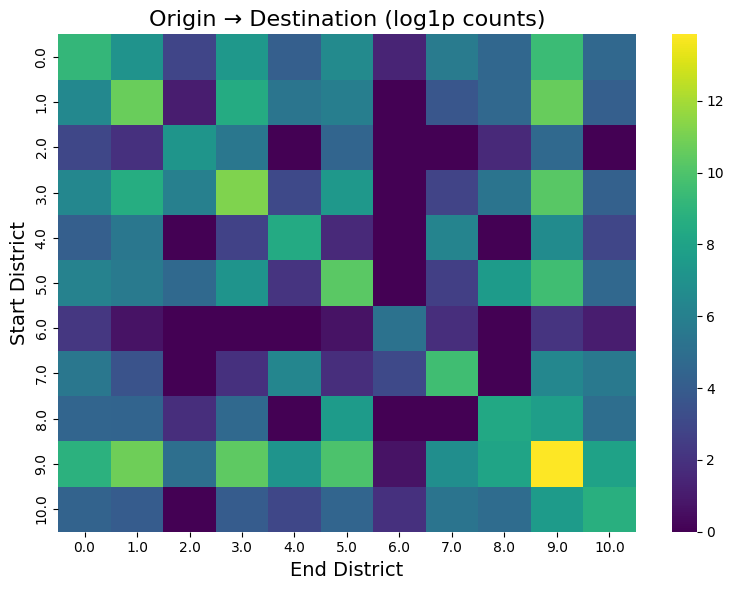

In [53]:
# origin -> destination heatmap (no geometry needed)
    # simple cross tabulation of two (or more) factors; start and end council districts here  
od = pd.crosstab(df['Council District (Start)'], df['Council District (End)'])
plt.figure(figsize=(8,6))
sns.heatmap(np.log1p(od), cmap='viridis')
plt.title('Origin → Destination (log1p counts)', fontsize=16)
plt.xlabel('End District', fontsize=14)
plt.ylabel('Start District', fontsize=14)
plt.tight_layout()
plt.show()

#### Additional Preprocessing (for modeling)

Trip distance has data points in right-tail of the distribution; thus, perform log-transform which appears more approximately normal. 

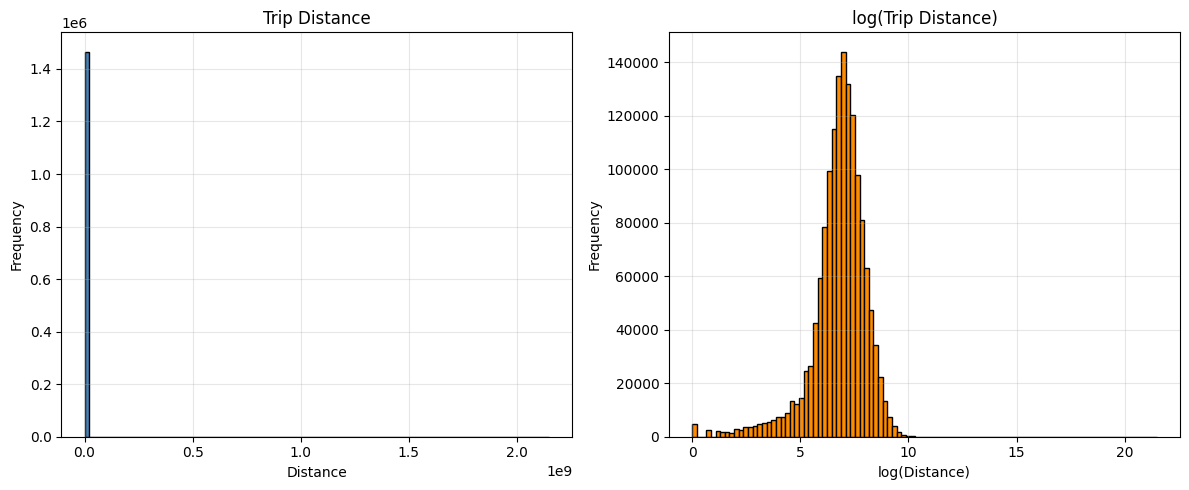

In [50]:
td = df['Trip Distance']
log_td = np.log(td)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(td, bins=100, color='steelblue', edgecolor='black')
ax[0].set_title('Trip Distance')
ax[0].set_xlabel('Distance')
ax[0].set_ylabel('Frequency')
ax[0].grid(alpha=0.3)

ax[1].hist(log_td, bins=100, color='darkorange', edgecolor='black')
ax[1].set_title('log(Trip Distance)')
ax[1].set_xlabel('log(Distance)')
ax[1].set_ylabel('Frequency')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# Separate predictors (X) and response (y)
X = df.drop(columns=['Trip Distance'])
y = np.log(df['Trip Distance'].values)  # log-transform response variable

# Train/Validation/Test split (no scaling yet)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1026295, 10) (1026295,)
Validation: (219920, 10) (219920,)
Test: (219921, 10) (219921,)


In [54]:
# Recombine X and y 
train_df = X_train.copy()
train_df['_log_trip_distance'] = y_train

val_df = X_val.copy()
val_df['_log_trip_distance'] = y_val

test_df = X_test.copy()
test_df['_log_trip_distance'] = y_test

train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("val_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)